In [1]:
from pathlib import Path
from sequences_peaks import SequenceConfig
# Yeni veri klasörün
DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = DATA_FOLDER / "train.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"
TEST_CSV = DATA_FOLDER / "test.csv"
WINDOW_SIZE = 20000
LABEL_NAMES = ['walking']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=32,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)

2026-02-11 12:30:52.003997: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-11 12:30:52.004065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-11 12:30:52.029256: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-11 12:30:52.081702: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras.models import Model

def build_multi_output_model(input_shape, n_classes):
    inputs = L.Input(shape=input_shape)

    # --- Feature Extractor (Encoder) ---
    x = L.Conv1D(64, kernel_size=11, strides=2, padding="same", activation="relu")(inputs)
    x = L.BatchNormalization()(x)
    
    # ... mevcut CNN katmanların ...
    
    # --- Branch 1: Classification (Sınıflandırma) ---
    # Global average pooling yaparak sınıfı tahmin eder
    flat = L.GlobalAveragePooling1D()(x)
    class_out = L.Dense(n_classes, activation="softmax", name="class_output")(flat)

    # --- Branch 2: Peak Detection (Segmentasyon) ---
    # Sinyal boyutuna geri dönmek için UpSampling/Transpose kullanıyoruz
    # (Window size'a göre katman sayısını ayarlamalısın)
    up = L.UpSampling1D(size=2)(x) 
    up = L.Conv1D(32, kernel_size=11, padding="same", activation="relu")(up)
    
    # Son katman: Sinyal ile aynı uzunlukta (WINDOW_SIZE) ve sigmoid
    peak_out = L.Conv1D(1, kernel_size=3, padding="same", activation="sigmoid", name="peak_output")(up)

    model = Model(inputs=inputs, outputs=[class_out, peak_out])
    return model

model = build_multi_output_model((WINDOW_SIZE, 1), n_classes=1)

2026-02-11 12:30:54.700530: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-11 12:30:54.737558: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-11 12:30:54.738939: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
from sequences_peaks import *
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "class_output": "categorical_crossentropy",
        "peak_output": "binary_crossentropy" # Maske 0-1 olduğu için
    },
    loss_weights={
        "class_output": 1.0, 
        "peak_output": 10.0  # Peak tespiti daha zordur, bu yüzden ağırlığı yüksek tutabilirsin
    },
    metrics={"class_output": "accuracy", "peak_output": "mae"}
)

# Eğitimi başlat
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

In [4]:
def sample_batch_from_seq(seq):
    # Son batch tam dolu olmayabilir (partial batch). 
    # Hata almamak için sadece tam dolu olan batch'ler arasından seçim yapalım.
    num_batches = len(seq)
    if len(seq.indices) % seq.batch_size != 0:
        num_batches -= 1 # Son batch yarım ise onu seçme listesinden çıkar
    
    if num_batches <= 0:
        # Eğer veri seti çok küçükse ve hiç tam batch yoksa mecbur ilkini al
        idx_s = idx_t = 0
    else:
        idx_s = np.random.randint(0, num_batches)
        idx_t = np.random.randint(0, num_batches)
    
    xs, targets_s = seq[idx_s]
    xt, targets_t = seq[idx_t]
    
    # Boyutların (Batch, Window, 1) olduğundan emin olalım
    # Nadiren de olsa index kaymaları için kontrol:
    if xs.shape[0] != xt.shape[0]:
        min_batch = min(xs.shape[0], xt.shape[0])
        xs = xs[:min_batch]
        xt = xt[:min_batch]
        ps = targets_s['peak_output'][:min_batch]
        pt = targets_t['peak_output'][:min_batch]
    else:
        ps = targets_s['peak_output']
        pt = targets_t['peak_output']
        
    return xs, xt, ps, pt

In [5]:
def loss_env(fake, tgt):
    ef = envelope(fake)
    et = envelope(tgt)
    return tf.reduce_mean(tf.abs(ef - et))

def loss_onset(fake, tgt):
    of = onset(envelope(fake))
    ot = onset(envelope(tgt))
    return tf.reduce_mean(tf.abs(of - ot))

def loss_ac(fake, tgt, max_lag=2000):
    af = autocorr_1d(envelope(fake), max_lag=max_lag)
    at = autocorr_1d(envelope(tgt),  max_lag=max_lag)
    return tf.reduce_mean(tf.abs(af - at))

def loss_delta(delta):
    # delta enerji reg (noise’a kaçmayı frenler)
    return tf.reduce_mean(tf.square(delta))
def peak_distance_loss(fake, tgt):
    ef = envelope(fake)
    et = envelope(tgt)
    pf = tf.where(ef > 0.7 * tf.reduce_max(ef, axis=1, keepdims=True))
    pt = tf.where(et > 0.7 * tf.reduce_max(et, axis=1, keepdims=True))
    loss_value = tf.abs(tf.reduce_mean(pf[:,1]) - tf.reduce_mean(pt[:,1]))

    return tf.cast(loss_value, tf.float32)
# (Batch_size değişken olabilir (None), Window_size sabit, Kanal sabit)
@tf.function(input_signature=[
    tf.TensorSpec(shape=[None, WINDOW_SIZE, 2], dtype=tf.float32),
    tf.TensorSpec(shape=[None, WINDOW_SIZE, 2], dtype=tf.float32)
])
def train_step(x_src, x_tgt):
    # z: Latent noise
    z = tf.random.normal((tf.shape(x_src)[0], WINDOW_SIZE, LATENT_CH))

    with tf.GradientTape() as tape:
        # 1. Kanalları Ayır
        # Kanal 0: Sinyal, Kanal 1: Peaks
        x_src_sig = x_src[:, :, 0:1] # (Batch, 20000, 1)
        x_tgt_sig = x_tgt[:, :, 0:1] # (Batch, 20000, 1)
        
        # 2. Üretim (GEN hem sinyali hem peak'i görür)
        delta = GEN([x_src, z], training=True) 
        
        # 3. Fake Sinyal Oluştur (Delta sadece sinyal kanalına eklenir)
        x_fake_sig = x_src_sig + delta

        # 4. Kayıpları Hesapla (Sadece sinyal kanalları ile!)
        # Artık loss_env'e (B, T, 1) gidiyor, squeeze hata vermeyecek
        le = loss_env(x_fake_sig, x_tgt_sig)
        lo = loss_onset(x_fake_sig, x_tgt_sig)
        la = loss_ac(x_fake_sig, x_tgt_sig, max_lag=2000)
        ld = loss_delta(delta)
        lpd = peak_distance_loss(x_fake_sig, x_tgt_sig)
        
        total = (W_ENV * le + W_ONSET * lo + W_AC * la + W_DELTA * ld + W_PEAK * lpd)

    grads = tape.gradient(total, GEN.trainable_variables)
    opt.apply_gradients(zip(grads, GEN.trainable_variables))
    return total, le, lo, la, ld, lpd

In [6]:
def moving_avg(x, k=129):
    # x: (B,T,1)
    x = tf.squeeze(x, -1)                 # (B,T)
    x = x[:, :, None]                     # (B,T,1)
    filt = tf.ones([k, 1, 1], tf.float32) / float(k)
    y = tf.nn.conv1d(x, filt, stride=1, padding="SAME")
    return y  # (B,T,1)

def envelope(x):
    # abs + smoothing (Hilbert yerine daha stabil)
    return moving_avg(tf.abs(x), k=129)

def onset(env):
    # vuruş başlangıcı: env türevi
    d = env[:, 1:, :] - env[:, :-1, :]
    d = tf.nn.relu(d)
    # eski boyuta pad
    return tf.pad(d, [[0,0],[0,1],[0,0]])

def autocorr_1d(x, max_lag=2000):
    # x: (B,T,1) -> env üzerinden kullanacağız
    x = tf.squeeze(x, -1)                # (B,T)
    x = x - tf.reduce_mean(x, axis=1, keepdims=True)
    # FFT tabanlı autocorr: irfft(|X|^2)
    X = tf.signal.rfft(x)
    S = tf.math.conj(X) * X
    ac = tf.signal.irfft(S)
    ac = ac[:, :max_lag]
    ac = ac / (ac[:, :1] + 1e-12)
    return ac  # (B,max_lag)


In [7]:

# Ayarlar
STEPS = 5000       # Toplam adım sayısı
LOG_EVERY = 100    # Kaç adımda bir ekrana yazdırılsın
BATCH = 16         # Batch boyutu
WINDOW_SIZE = 20000
LATENT_CH   = 8          # z kanalı (çok büyük tutma)
BATCH       = 8
LR          = 2e-4
STEPS       = 4000
LOG_EVERY   = 100

# Loss ağırlıkları (başlangıç)
W_ENV   = tf.constant(1.0, dtype=tf.float32)
W_ONSET= tf.constant(0.5, dtype=tf.float32)
W_AC   = tf.constant(0.3, dtype=tf.float32)
W_DELTA= tf.constant(0.005, dtype=tf.float32)
W_PEAK = tf.constant(0.3, dtype=tf.float32)

In [8]:
def mask_signal(x, drop_frac=0.3):
    mask = tf.cast(tf.random.uniform(tf.shape(x)) > drop_frac, tf.float32)
    return x * mask

def build_cond_generator(window=WINDOW_SIZE, latent_ch=LATENT_CH):
    x_in = tf.keras.Input(shape=(window, 2), name="x_src")
    z_in = tf.keras.Input(shape=(window, latent_ch), name="z")

    x_masked = tf.keras.layers.Lambda(lambda t: mask_signal(t, 0.4))(x_in)
    h = tf.keras.layers.Concatenate()([x_masked, z_in])
    
    # --- ENCODER KISMI (Boyutu Küçültme) ---
    h = tf.keras.layers.Conv1D(64, 25, strides=2, padding="same")(h) # Strides=2 ile çözünürlük düşer
    h = tf.keras.layers.LeakyReLU(0.2)(h)
    h = tf.keras.layers.Conv1D(128, 25, strides=2, padding="same")(h)
    h = tf.keras.layers.LeakyReLU(0.2)(h)

    # --- DENSE LAYER (BOTTLENECK) ---
    # Burada global bir bakış açısı kazanıyoruz
    # Dikkat: Dense eklemek için sinyalin o anki boyutunu bilmeliyiz
    # Veya Conv1D(kernel_size=1) kullanarak 'Pointwise Dense' etkisi yaratabiliriz:
    h = tf.keras.layers.Conv1D(256, 1, padding="same")(h) # Dense etkisi yaratır, parametreleri coşturmaz
    h = tf.keras.layers.LeakyReLU(0.2)(h)

    # --- DECODER KISMI (Boyutu Geri Büyütme) ---
    h = tf.keras.layers.Conv1DTranspose(128, 25, strides=2, padding="same")(h)
    h = tf.keras.layers.LeakyReLU(0.2)(h)
    h = tf.keras.layers.Conv1DTranspose(64, 25, strides=2, padding="same")(h)
    h = tf.keras.layers.LeakyReLU(0.2)(h)

    delta = tf.keras.layers.Conv1D(1, 25, padding="same", activation="tanh")(h)
    delta = tf.keras.layers.Lambda(lambda t: 0.2 * t)(delta)
    
    return tf.keras.Model([x_in, z_in], delta, name="cond_excavation_delta_gen")

GEN = build_cond_generator()
opt = tf.keras.optimizers.Adam(LR)
GEN.summary()


Model: "cond_excavation_delta_gen"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 x_src (InputLayer)          [(None, 20000, 2)]           0         []                            
                                                                                                  
 lambda (Lambda)             (None, 20000, 2)             0         ['x_src[0][0]']               
                                                                                                  
 z (InputLayer)              [(None, 20000, 8)]           0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 20000, 10)            0         ['lambda[0][0]',              
                                                                     'z[0]

In [9]:
import numpy as np
import tensorflow as tf
# History sözlüğü (lpd - peak loss - dahil edildi)
hist = {"total":[], "env":[], "onset":[], "ac":[], "delta":[], "peak_dist":[]}

print(f"Eğitim Başlatılıyor... Veri: {DATA_FOLDER.name}")

for step in range(STEPS):
    # Yeni fonksiyondan verileri al
    # xs: Kaynak sinyal, xt: Hedef sinyal (residual hesaplamak için)
    # ps, pt: Bunlar senin CSV'den gelen gerçek peak maskelerin!
    xs, xt, ps, pt = sample_batch_from_seq(train_seq)
    
    # Tensor'e çevir
    xs = tf.convert_to_tensor(xs, dtype=tf.float32)
    xt = tf.convert_to_tensor(xt, dtype=tf.float32)
    # ps = tf.convert_to_tensor(ps, dtype=tf.float32) # Eğer train_step'te kullanacaksan aktif et

    # Eğitim Adımı
    # Not: Eğer train_step fonksiyonun hala 6 değer döndürüyorsa (total, le, lo, la, ld, lpd)
    total, le, lo, la, ld, lpd = train_step(xs, xt)

    # Kayıt
    hist["total"].append(float(total))
    hist["env"].append(float(le))
    hist["onset"].append(float(lo))
    hist["ac"].append(float(la))
    hist["delta"].append(float(ld))
    hist["peak_dist"].append(float(lpd))

    # Loglama
    if step % LOG_EVERY == 0:
        print(f"[{step:04d}] total={hist['total'][-1]:.4f} "
              f"env={hist['env'][-1]:.4f} "
              f"onset={hist['onset'][-1]:.4f} "
              f"ac={hist['ac'][-1]:.4f} "
              f"dreg={hist['delta'][-1]:.4f} "
              f"peak_l={hist['peak_dist'][-1]:.4f}")

Eğitim Başlatılıyor... Veri: 2026-02-11-walking-with-peaks


2026-02-11 12:30:59.039243: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-02-11 12:31:01.120455: I external/local_xla/xla/service/service.cc:168] XLA service 0x7efc0fb3e920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-11 12:31:01.120485: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-02-11 12:31:01.132406: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770813061.210720  166317 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[0000] total=634.7741 env=173.8006 onset=0.1669 ac=0.2997 dreg=0.0105 peak_l=1536.0000
[0100] total=225.5026 env=213.9102 onset=0.2216 ac=0.2716 dreg=0.0209 peak_l=38.0000
[0200] total=752.3466 env=280.8375 onset=0.2757 ac=0.2370 dreg=0.0287 peak_l=1571.0000
[0300] total=485.2370 env=310.1379 onset=0.2290 ac=0.2814 dreg=0.0221 peak_l=583.0000
[0400] total=264.9116 env=217.3339 onset=0.1824 ac=0.2878 dreg=0.0295 peak_l=158.0000
[0500] total=362.0278 env=253.5286 onset=0.2369 ac=0.2689 dreg=0.0145 peak_l=361.0000
[0600] total=648.6805 env=330.4862 onset=0.2054 ac=0.3050 dreg=0.0217 peak_l=1060.0000
[0700] total=265.8351 env=203.2433 onset=0.2014 ac=0.3033 dreg=0.0191 peak_l=208.0000
[0800] total=467.0253 env=279.0459 onset=0.1768 ac=0.3030 dreg=0.0248 peak_l=626.0000
[0900] total=150.9675 env=147.8036 onset=0.1709 ac=0.2610 dreg=0.0261 peak_l=10.0000
[1000] total=226.4655 env=146.7914 onset=0.1706 ac=0.2955 dreg=0.0224 peak_l=265.0000
[1100] total=243.4005 env=166.1182 onset=0.1919 ac=0.

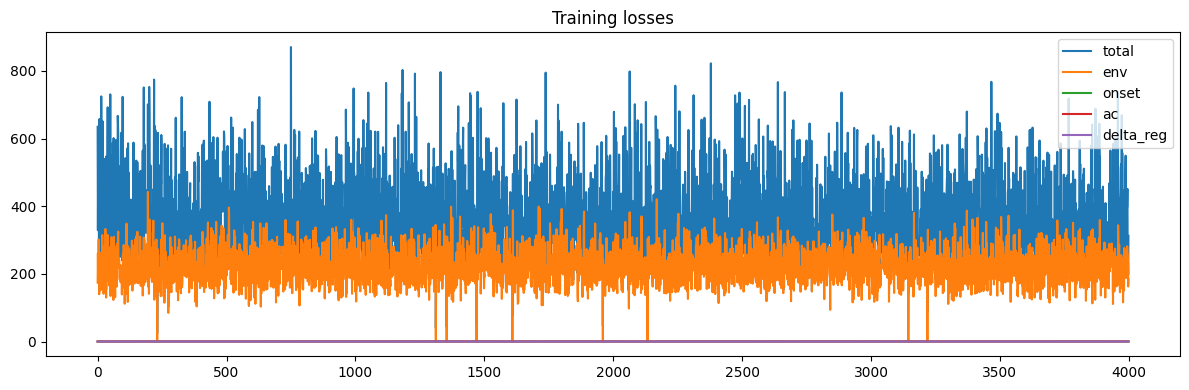

Görselleştirilen Dosya: /home/fotas/data/segment/2024.08.02/record_CIFTLIK _DERINLIK30_cakil_yurume_126_202408021213_30min_raw.bin.hdf5


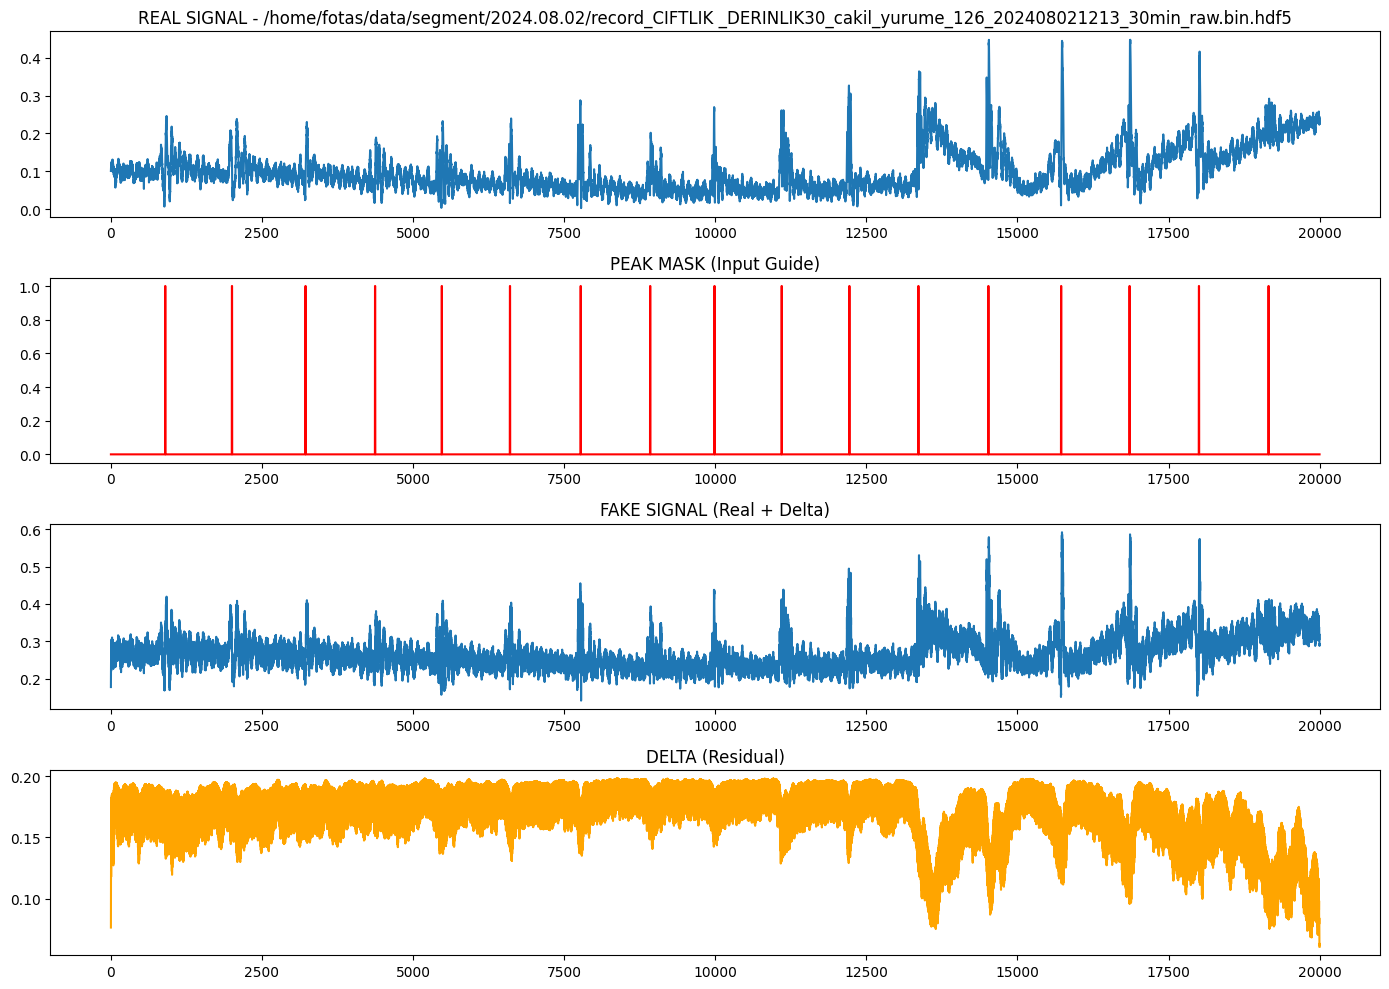

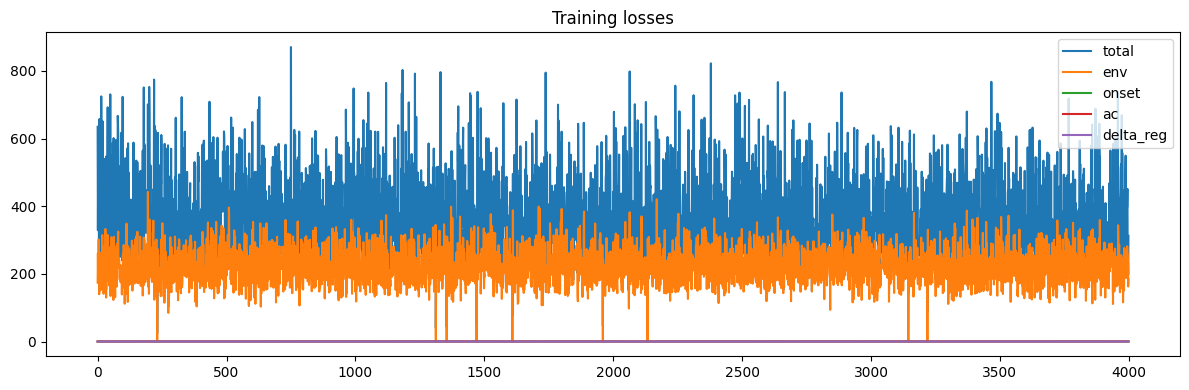

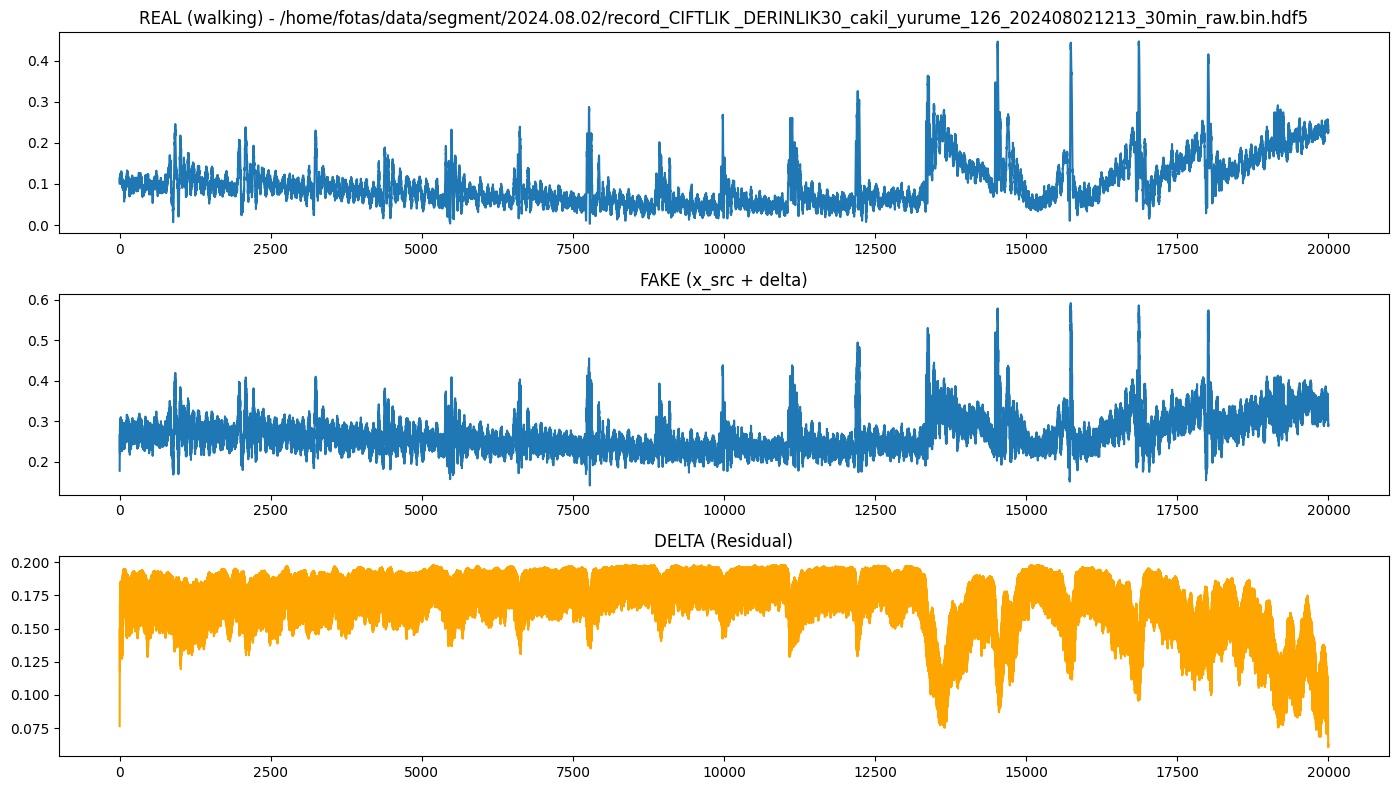

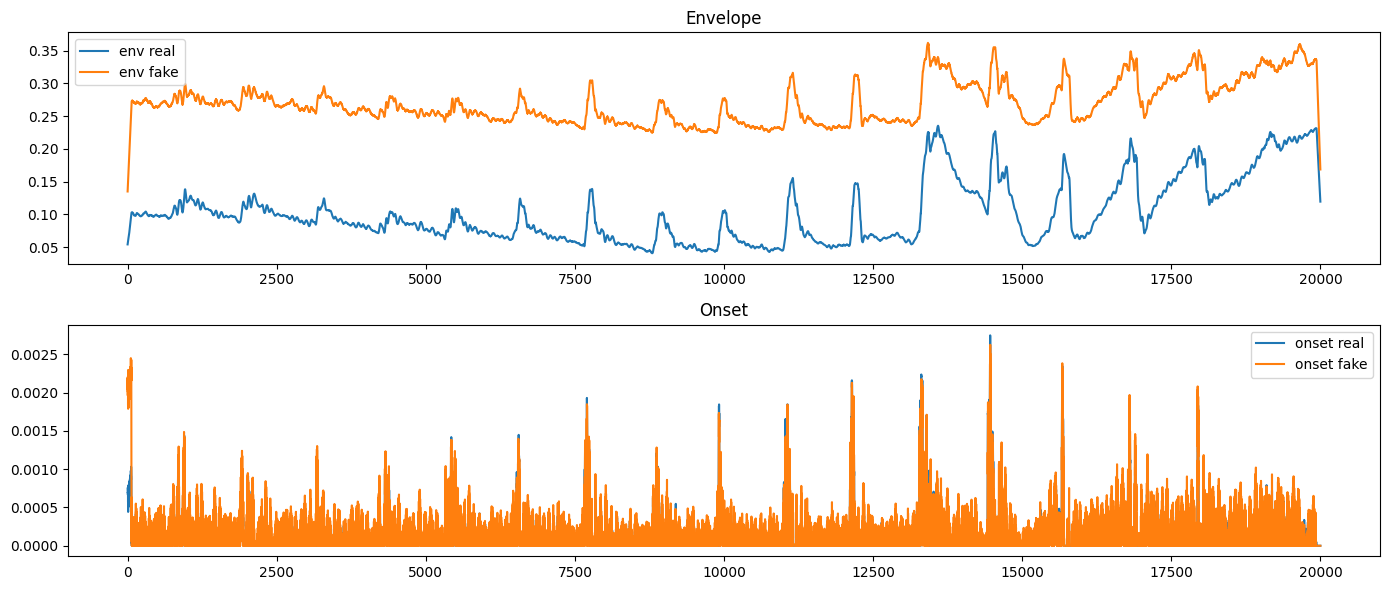

In [20]:
import matplotlib.pyplot as plt
def plot_losses(hist):
    plt.figure(figsize=(12,4))
    plt.plot(hist["total"], label="total")
    plt.plot(hist["env"], label="env")
    plt.plot(hist["onset"], label="onset")
    plt.plot(hist["ac"], label="ac")
    plt.plot(hist["delta"], label="delta_reg")
    plt.legend(); plt.title("Training losses"); plt.tight_layout(); plt.show()

def generate_one(row, window_size=WINDOW_SIZE):
    # 1. Ham sinyali yükle
    signal = _load_signal_from_row(row, window_size).astype(np.float32)
    
    # 2. Peak maskesini oluştur (Modelin girişi 2 kanal olduğu için bu şart)
    peaks_str = row.get("peaks", "")
    peak_mask = _generate_peak_mask(peaks_str, window_size).astype(np.float32) # (20000, 1)
    
    # 3. Girişi birleştir (Signal + Peak Mask) -> (20000, 2)
    signal_2d = signal[:, np.newaxis] # (20000, 1)
    dual_input = np.concatenate([signal_2d, peak_mask], axis=-1) # (20000, 2)
    
    # 4. Tensor'e çevir ve Batch boyutu ekle -> (1, 20000, 2)
    x_src_tf = tf.convert_to_tensor(dual_input[None, ...], dtype=tf.float32)
    
    # 5. Latent Z üret -> (1, 20000, 8)
    z = tf.random.normal((1, window_size, LATENT_CH))
    
    # 6. Model tahmini
    delta = GEN([x_src_tf, z], training=False)
    
    # 7. Sonuç: Fake sinyal = Sadece ham sinyal kanalı + delta
    x_fake = x_src_tf[:, :, 0:1] + delta
    
    return (x_fake[0, :, 0].numpy(), delta[0, :, 0].numpy(), signal, peak_mask.squeeze())

plot_losses(hist)
from sequences_peaks import _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask
LABEL = "walking"
df = _load_sequence_dataframe(DATA_FOLDER / "train.csv")
walk_df = df[df["event"] == LABEL].reset_index(drop=True)
filtered_walk_df = walk_df[~walk_df['file'].str.contains('cross|italy', case=False, na=False)].reset_index(drop=True)
row = filtered_walk_df.sample(1).iloc[0] 

# Dosya ismini de görebilmek için yazdıralım
print(f"Görselleştirilen Dosya: {row['file']}")

real = _load_signal_from_row(row, WINDOW_SIZE).astype(np.float32)
fake, delta, real, p_mask = generate_one(row)

# Plotting
plt.figure(figsize=(14,10))
plt.subplot(4,1,1); plt.plot(real); plt.title(f"REAL SIGNAL - {row['file']}")
plt.subplot(4,1,2); plt.plot(p_mask, color='red'); plt.title("PEAK MASK (Input Guide)")
plt.subplot(4,1,3); plt.plot(fake); plt.title("FAKE SIGNAL (Real + Delta)")
plt.subplot(4,1,4); plt.plot(delta, color='orange'); plt.title("DELTA (Residual)")
plt.tight_layout(); plt.show()
# Plotting süreçleri aynı kalabilir
plot_losses(hist)

plt.figure(figsize=(14,8))
plt.subplot(3,1,1); plt.plot(real);  plt.title(f"REAL (walking) - {row['file']}")
plt.subplot(3,1,2); plt.plot(fake);  plt.title("FAKE (x_src + delta)")
plt.subplot(3,1,3); plt.plot(delta, color='orange'); plt.title("DELTA (Residual)")
plt.tight_layout(); plt.show()

# Envelope & onset karşılaştırma
er = envelope(tf.convert_to_tensor(real[None,:,None])).numpy()[0,:,0]
ef = envelope(tf.convert_to_tensor(fake[None,:,None])).numpy()[0,:,0]
or_ = onset(tf.convert_to_tensor(er[None,:,None])).numpy()[0,:,0]
of_ = onset(tf.convert_to_tensor(ef[None,:,None])).numpy()[0,:,0]

plt.figure(figsize=(14,6))
plt.subplot(2,1,1); plt.plot(er, label="env real"); plt.plot(ef, label="env fake"); plt.legend(); plt.title("Envelope")
plt.subplot(2,1,2); plt.plot(or_, label="onset real"); plt.plot(of_, label="onset fake"); plt.legend(); plt.title("Onset")
plt.tight_layout(); plt.show()


NameError: name 'generator' is not defined